# 14 · Extensional rheology

Fibre spinning, film blowing, inkjet printing, spraying, swallowing and the break-up of a thread of saliva are
dominated not by shear but by **extension** - stretching. Polymer solutions that thin in shear can become
enormously resistant in extension (strain hardening), which stabilises fibres and filaments but can stop an
inkjet drop from detaching.

**What you will learn**
- explain the Trouton ratio and strain hardening
- compare constitutive models in extension
- analyse a capillary-thinning experiment for the extensional relaxation time

**Before you start:** notebooks 10 and 07  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, extensional as ex, constitutive as cm
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Shear versus extension
A Newtonian liquid's extensional viscosity is exactly three times its shear viscosity (Trouton ratio 3). A
polymer solution behaves very differently once the extension rate exceeds about half the inverse relaxation
time ($Wi = \lambda\dot\varepsilon > 0.5$), where stretching outpaces relaxation:

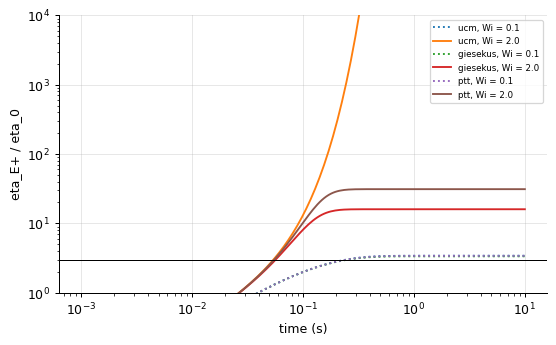

In [2]:
eta_p, lam = 10.0, 0.1
t = np.logspace(-3, 1, 200)
fig, ax = plt.subplots()
for model, extra in (("ucm", {}), ("giesekus", {"alpha": 0.1}), ("ptt", {"eps": 0.05})):
    for Wi in (0.1, 2.0):
        r = cm.startup_extension([cm.Mode(eta_p, lam, model, **extra)], Wi / lam, np.r_[0.0, t])
        ax.loglog(t, r["eta_E_plus"][1:] / eta_p, label=f"{model}, Wi = {Wi}", ls="-" if Wi > 1 else ":")
ax.axhline(3, color="k", lw=0.8)
ax.set(xlabel="time (s)", ylabel="eta_E+ / eta_0", ylim=(1, 1e4)); ax.legend(fontsize=7); plt.show()

At $Wi$ = 0.1 all three models approach the Trouton value of 3. At $Wi$ = 2 the UCM (Oldroyd-B) model's
extensional viscosity grows without bound - its dumbbells stretch infinitely - while Giesekus and PTT
saturate at a high but finite value, like real polymers with finite chain length. The large ratio of
extensional to shear viscosity is what lets a polymer solution form long, stable threads.

## Measuring it: capillary thinning (CaBER)
A drop is stretched between two plates into a liquid bridge, which then thins under surface tension.
The mid-filament diameter tells the story:

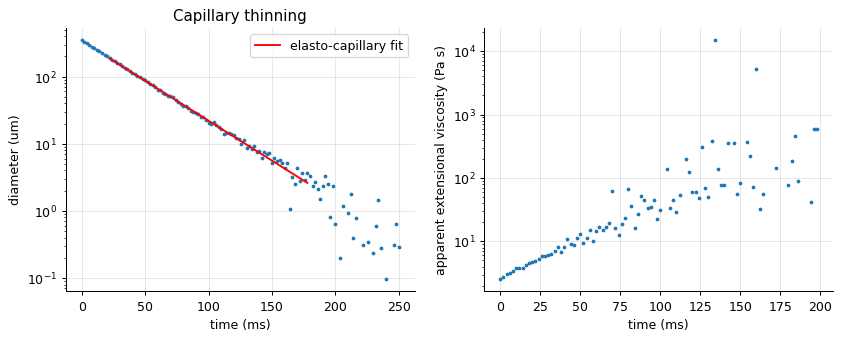

extensional relaxation time lambda_E = 12.18 ms (true 12 ms)


In [3]:
cb = pd.read_csv(datasets.path("polymer_solution_caber.csv"), comment="#")
t_c, D = cb.time_s.to_numpy(), cb.diameter_m.to_numpy()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.semilogy(t_c * 1e3, D * 1e6, ".", ms=4); a1.set(xlabel="time (ms)", ylabel="diameter (um)", title="Capillary thinning")
ec = (t_c > 0.02) & (t_c < 0.18)                           # the straight (exponential) part on the semilog plot
fit = ex.fit_elastocapillary(t_c[ec], D[ec])
a1.semilogy(t_c[ec] * 1e3, fit["D_fit0"] * np.exp(-t_c[ec] / (3 * fit["lambda_E"])) * 1e6, "r-", label="elasto-capillary fit")
a1.legend()
sigma = 0.062
eta_E = ex.apparent_extensional_viscosity(t_c, D, sigma, X=0.7127)
ok = np.isfinite(eta_E) & (t_c < 0.2)
a2.semilogy(t_c[ok] * 1e3, eta_E[ok], ".", ms=4); a2.set(xlabel="time (ms)", ylabel="apparent extensional viscosity (Pa s)")
plt.show()
print(f"extensional relaxation time lambda_E = {fit['lambda_E']*1e3:.2f} ms (true 12 ms)")

A Newtonian liquid would thin linearly in time. This solution thins **exponentially** - the elasto-capillary
balance, in which surface tension is resisted by stretched polymer chains - with a rate set by the extensional
relaxation time. The apparent extensional viscosity grows by orders of magnitude as the filament thins
(strain hardening), until the chains are fully stretched and the filament finally drains and breaks. (The
factor $2X - 1$ with $X$ = 0.7127 is exact only for Newtonian thinning; for polymer solutions it is an
approximation, so the absolute values are indicative.)

For inkjet printing this relaxation time decides whether a drop detaches cleanly or trails a long ligament
that breaks into satellite droplets.

## Inside the algorithm: the elasto-capillary fit
In the elasto-capillary regime $D = D_1 e^{-t/(3\lambda_E)}$, a straight line of $\ln D$ against $t$ with slope $-1/(3\lambda_E)$:

In [4]:
slope, _ = np.polyfit(t_c[ec], np.log(D[ec]), 1)
print(f"by hand: lambda_E = {-1/(3*slope)*1e3:.3f} ms;  library: {fit['lambda_E']*1e3:.3f} ms")

by hand: lambda_E = 12.182 ms;  library: 12.182 ms


## Exercises
1. A filament of glycerol ($\eta$ = 1 Pa·s, $\sigma$ = 0.063 N/m) starts at 3 mm diameter. How long does it take to break (Newtonian thinning)? Compare with the polymer solution.
2. For an inkjet nozzle of 20 um radius, compare the capillary time $\sqrt{\rho R^3/\sigma}$ ($\rho$ = 1000 kg/m³) with the extensional relaxation time. What does the resulting Deborah number predict about satellite drops?
3. **Implement it yourself:** generate a Newtonian thinning curve with `ex.newtonian_thinning`, compute the apparent extensional viscosity from its slope by hand, and confirm the Trouton ratio of 3.